# 3. Model Training & Evaluasi

Notebook ini melakukan:
1. Load data hasil cleaning
2. Split train/test (dengan stratify)
3. Bangun Pipeline lengkap (preprocessing + SMOTE + model)
4. Cross-validation & hyperparameter tuning
5. Evaluasi model
6. Ensemble sederhana (VotingClassifier)
7. Simpan model terbaik ke `model.pkl`

> **Prinsip utama:** Semua preprocessing (scaling, encoding, SMOTE) dilakukan
> **di dalam Pipeline** sehingga tidak terjadi data leakage ke data test.

## 3.1 Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Sklearn — preprocessing & pipeline
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Sklearn — model & evaluasi
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Imbalanced-learn — SMOTE untuk class imbalance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

%matplotlib inline
sns.set_theme(style='whitegrid')

print('Semua library berhasil diimport.')

Semua library berhasil diimport.


## 3.2 Load Data Hasil Cleaning

In [4]:
# Muat hasil cleaning dari notebook sebelumnya
df = pd.read_csv('cleaning.csv')

print(f'Data dimuat: {df.shape[0]:,} baris x {df.shape[1]} kolom')
print(f'Distribusi target:\n{df["failure_flag"].value_counts().to_string()}')
df.head(3)

Data dimuat: 543,210 baris x 24 kolom
Distribusi target:
failure_flag
0    455130
1     88080


,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,moisture_regime,...,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,dry,...,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,optimal,...,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,waterlogged,...,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1


## 3.3 Definisi Fitur & Target

In [5]:
# Pisahkan fitur (X) dan target (y)
TARGET = 'failure_flag'

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Identifikasi kolom numerik dan kategorikal secara otomatis
num_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Gunakan hanya 'object' — pandas 3.x tidak mengizinkan 'str' di select_dtypes
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print(f'Total fitur: {X.shape[1]}')
print(f'  Numerik      ({len(num_features)}): {num_features}')
print(f'  Kategorikal  ({len(cat_features)}): {cat_features}')
print(f'\nTarget: {TARGET} | Shape X: {X.shape}, y: {y.shape}')

Total fitur: 23
  Numerik      (18): ['bulk_density', 'organic_matter_pct', 'cation_exchange_capacity', 'salinity_ec', 'buffering_capacity', 'soil_moisture_pct', 'moisture_limit_dry', 'moisture_limit_wet', 'soil_temp_c', 'air_temp_c', 'light_intensity_par', 'soil_ph', 'ph_stress_flag', 'nitrogen_ppm', 'phosphorus_ppm', 'potassium_ppm', 'suitability_score', 'stress_level']
  Kategorikal  (5): ['soil_type', 'moisture_regime', 'thermal_regime', 'nutrient_balance', 'plant_category']

Target: failure_flag | Shape X: (543210, 23), y: (543210,)


## 3.4 Split Data Train & Test

Split dilakukan **sebelum** apapun (scaling, SMOTE) untuk mencegah data leakage.

In [6]:
# Split 80% train, 20% test
# stratify=y memastikan proporsi kelas sama di train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Pertahankan proporsi kelas
)

print(f'Train: {X_train.shape[0]:,} baris  |  Test: {X_test.shape[0]:,} baris')
print(f'\nDistribusi target di train:')
print(y_train.value_counts(normalize=True).round(3).to_string())
print(f'\nDistribusi target di test:')
print(y_test.value_counts(normalize=True).round(3).to_string())

Train: 434,568 baris  |  Test: 108,642 baris

Distribusi target di train:
failure_flag
0    0.838
1    0.162

Distribusi target di test:
failure_flag
0    0.838
1    0.162


## 3.5 Bangun Pipeline (Preprocessing + SMOTE + Model)

Arsitektur pipeline:
```
ColumnTransformer
  ├─ numerik   → StandardScaler
  └─ kategorikal → OneHotEncoder
       ↓
     SMOTE   (hanya pada data train, otomatis oleh ImbPipeline)
       ↓
     Model
```

In [7]:
# --- Preprocessor ---
# StandardScaler: normalisasi fitur numerik agar semua berskala sama
# OneHotEncoder: ubah kategori menjadi kolom biner
#   handle_unknown='ignore' → abaikan kategori baru saat inference

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='drop'    # Kolom lain (jika ada) akan diabaikan
)

print('Preprocessor berhasil dibuat.')
print('  - Numerik  : StandardScaler')
print('  - Kategorikal: OneHotEncoder')

Preprocessor berhasil dibuat.
  - Numerik  : StandardScaler
  - Kategorikal: OneHotEncoder


In [8]:
# --- Pipeline RandomForest ---
# Menggunakan ImbPipeline dari imblearn agar SMOTE bekerja
# hanya pada fold training saat cross-validation

rf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),          # Oversample kelas minoritas
    ('model', RandomForestClassifier(
        n_estimators=100,    # Cukup banyak pohon tanpa terlalu berat
        max_depth=10,        # Batasi kedalaman untuk menghindari overfitting
        min_samples_leaf=5,  # Minimal sampel per daun
        random_state=42,
        n_jobs=-1
    ))
])

print('Pipeline RandomForest berhasil dibuat.')

Pipeline RandomForest berhasil dibuat.


In [9]:
# --- Pipeline Logistic Regression ---
lr_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(
        max_iter=500,
        random_state=42,
        n_jobs=-1
    ))
])

print('Pipeline Logistic Regression berhasil dibuat.')

Pipeline Logistic Regression berhasil dibuat.


## 3.6 Cross-Validation

In [10]:
# StratifiedKFold: menjaga proporsi kelas di setiap fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=== Cross-Validation (5-Fold Stratified) ===')
print('Menjalankan CV untuk RandomForest... (mungkin perlu beberapa menit)')

rf_cv_scores = cross_val_score(
    rf_pipeline, X_train, y_train,
    cv=cv, scoring='f1', n_jobs=-1
)

print(f'\nRandomForest CV F1-Score:')
print(f'  Setiap fold : {[round(s, 4) for s in rf_cv_scores]}')
print(f'  Rata-rata   : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}')

=== Cross-Validation (5-Fold Stratified) ===
Menjalankan CV untuk RandomForest... (mungkin perlu beberapa menit)

RandomForest CV F1-Score:
  Setiap fold : [np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(1.0)]
  Rata-rata   : 1.0000 ± 0.0000


In [11]:
print('Menjalankan CV untuk Logistic Regression...')

lr_cv_scores = cross_val_score(
    lr_pipeline, X_train, y_train,
    cv=cv, scoring='f1', n_jobs=-1
)

print(f'\nLogistic Regression CV F1-Score:')
print(f'  Setiap fold : {[round(s, 4) for s in lr_cv_scores]}')
print(f'  Rata-rata   : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}')

# Ringkasan perbandingan
print('\n=== Perbandingan CV F1-Score ===')
print(f'  RandomForest       : {rf_cv_scores.mean():.4f}')
print(f'  LogisticRegression : {lr_cv_scores.mean():.4f}')

Menjalankan CV untuk Logistic Regression...

Logistic Regression CV F1-Score:
  Setiap fold : [np.float64(0.9407), np.float64(0.9422), np.float64(0.945), np.float64(0.9423), np.float64(0.9409)]
  Rata-rata   : 0.9422 ± 0.0015

=== Perbandingan CV F1-Score ===
  RandomForest       : 1.0000
  LogisticRegression : 0.9422


## 3.7 Hyperparameter Tuning (GridSearchCV)

In [12]:
# Tuning dilakukan pada RandomForest dengan parameter terbatas
# agar tidak overfitting dan proses tidak terlalu lama

param_grid = {
    'model__n_estimators': [100, 200],        # Jumlah pohon
    'model__max_depth'   : [8, 12],           # Kedalaman maksimal
    'model__min_samples_leaf': [3, 5]         # Min sampel per daun
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    refit=True          # Otomatis latih ulang dengan parameter terbaik
)

print('Memulai GridSearchCV... (proses ini membutuhkan waktu)')
grid_search.fit(X_train, y_train)

print(f'\nParameter terbaik : {grid_search.best_params_}')
print(f'Best CV F1-Score  : {grid_search.best_score_:.4f}')

Memulai GridSearchCV... (proses ini membutuhkan waktu)
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Parameter terbaik : {'model__max_depth': 12, 'model__min_samples_leaf': 3, 'model__n_estimators': 100}
Best CV F1-Score  : 1.0000


In [13]:
# Ambil pipeline terbaik hasil GridSearchCV
best_rf_pipeline = grid_search.best_estimator_

print('Pipeline terbaik berhasil diambil.')

Pipeline terbaik berhasil diambil.


## 3.8 Evaluasi Model di Data Test

In [14]:
# Fungsi helper untuk menampilkan evaluasi
def evaluate_model(name, pipeline, X_tr, y_tr, X_te, y_te):
    """Latih pipeline dan tampilkan metrik evaluasi di train & test."""
    # Prediksi
    y_pred_train = pipeline.predict(X_tr)
    y_pred_test  = pipeline.predict(X_te)

    acc_train = accuracy_score(y_tr, y_pred_train)
    acc_test  = accuracy_score(y_te, y_pred_test)

    print(f'\n{"=" * 55}')
    print(f'  {name}')
    print(f'{"=" * 55}')
    print(f'  Accuracy Train : {acc_train:.4f}')
    print(f'  Accuracy Test  : {acc_test:.4f}')
    print(f'  Selisih (gap)  : {abs(acc_train - acc_test):.4f}')
    if abs(acc_train - acc_test) > 0.05:
        print('  ⚠ Gap > 5%  — kemungkinan sedikit overfitting.')
    else:
        print('  ✓ Gap kecil — model generalisasi dengan baik.')

    print(f'\n  Classification Report (Test Set):')
    print(classification_report(y_te, y_pred_test,
                                target_names=['No Failure (0)', 'Failure (1)']))

    return y_pred_test

In [15]:
# Evaluasi RandomForest terbaik
y_pred_rf = evaluate_model(
    'RandomForest (Best dari GridSearch)',
    best_rf_pipeline,
    X_train, y_train,
    X_test, y_test
)


  RandomForest (Best dari GridSearch)
  Accuracy Train : 1.0000
  Accuracy Test  : 1.0000
  Selisih (gap)  : 0.0000
  ✓ Gap kecil — model generalisasi dengan baik.

  Classification Report (Test Set):
                precision    recall  f1-score   support

No Failure (0)       1.00      1.00      1.00     91026
   Failure (1)       1.00      1.00      1.00     17616

      accuracy                           1.00    108642
     macro avg       1.00      1.00      1.00    108642
  weighted avg       1.00      1.00      1.00    108642



In [16]:
# Latih dan evaluasi Logistic Regression
lr_pipeline.fit(X_train, y_train)
y_pred_lr = evaluate_model(
    'Logistic Regression',
    lr_pipeline,
    X_train, y_train,
    X_test, y_test
)


  Logistic Regression
  Accuracy Train : 0.9801
  Accuracy Test  : 0.9808
  Selisih (gap)  : 0.0007
  ✓ Gap kecil — model generalisasi dengan baik.

  Classification Report (Test Set):
                precision    recall  f1-score   support

No Failure (0)       1.00      0.98      0.99     91026
   Failure (1)       0.90      1.00      0.94     17616

      accuracy                           0.98    108642
     macro avg       0.95      0.99      0.97    108642
  weighted avg       0.98      0.98      0.98    108642



## 3.9 Confusion Matrix

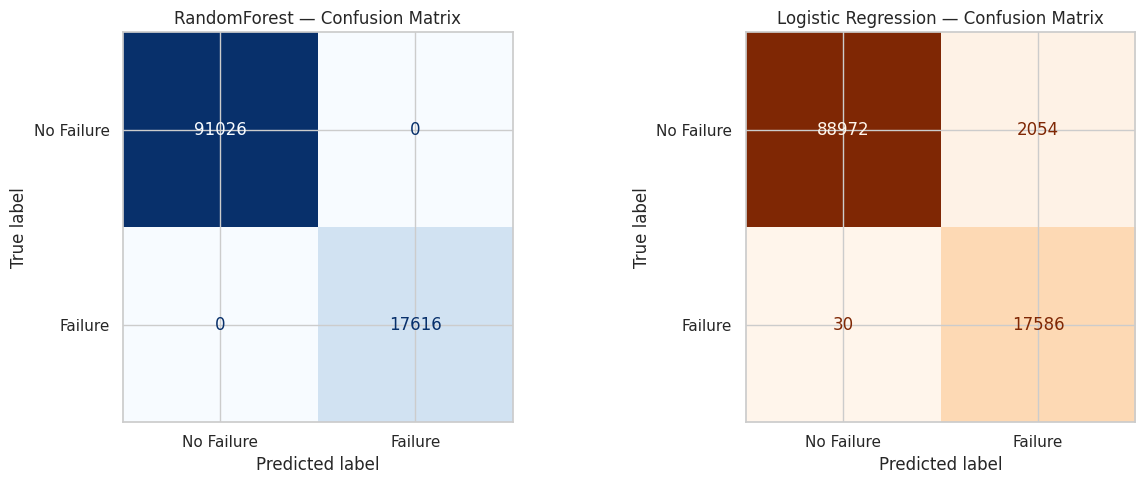

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix untuk RandomForest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['No Failure', 'Failure'])
disp_rf.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('RandomForest — Confusion Matrix', fontsize=12)

# Confusion Matrix untuk Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(cm_lr, display_labels=['No Failure', 'Failure'])
disp_lr.plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('Logistic Regression — Confusion Matrix', fontsize=12)

plt.tight_layout()
plt.show()

## 3.10 Feature Importance (RandomForest)

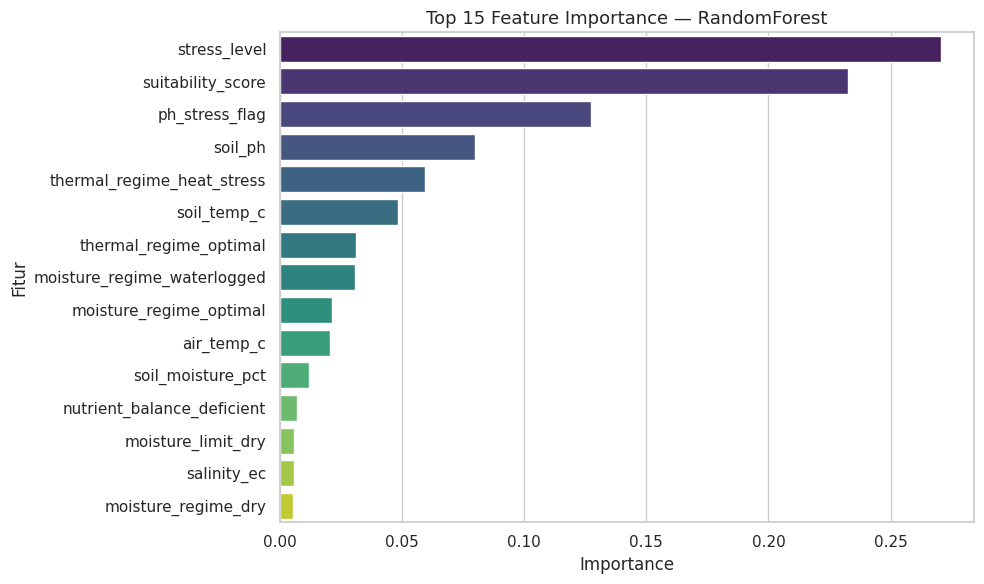

In [18]:
# Ambil nama fitur setelah preprocessing (OneHotEncoder menghasilkan banyak kolom)
ohe_features = best_rf_pipeline.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(cat_features).tolist()

all_feature_names = num_features + ohe_features

# Ambil importance dari model
importances = best_rf_pipeline.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature'   : all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, y='feature', x='importance', palette='viridis')
plt.title('Top 15 Feature Importance — RandomForest', fontsize=13)
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

## 3.11 Ensemble: VotingClassifier (Opsional)

In [19]:
# VotingClassifier menggabungkan prediksi dari beberapa model
# Menggunakan 'soft' voting (berdasarkan probabilitas) agar lebih akurat
#
# Catatan: VotingClassifier dari sklearn tidak kompatibel langsung dengan
# ImbPipeline (SMOTE). Solusinya: SMOTE diterapkan manual ke X_train
# menggunakan preprocessor yang sudah di-fit, lalu VotingClassifier dilatih.

from sklearn.ensemble import VotingClassifier

# Fit preprocessor pada data train untuk transformasi manual
preprocessor_fitted = best_rf_pipeline.named_steps['preprocessor']

# Transform data train
X_train_transformed = preprocessor_fitted.transform(X_train)
X_test_transformed  = preprocessor_fitted.transform(X_test)

# Terapkan SMOTE pada data train yang sudah di-transform
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_transformed, y_train)

print(f'Ukuran setelah SMOTE: {X_train_resampled.shape}')
print(f'Distribusi kelas   : {pd.Series(y_train_resampled).value_counts().to_dict()}')

Ukuran setelah SMOTE: (728208, 39)
Distribusi kelas   : {0: 364104, 1: 364104}


In [20]:
# Bangun 2 model untuk ensemble
rf_base = RandomForestClassifier(
    **{k.replace('model__', ''): v
       for k, v in grid_search.best_params_.items()},
    random_state=42, n_jobs=-1
)

lr_base = LogisticRegression(
    max_iter=500, random_state=42, n_jobs=-1
)

# VotingClassifier dengan soft voting
voting_clf = VotingClassifier(
    estimators=[
        ('rf', rf_base),
        ('lr', lr_base)
    ],
    voting='soft'   # Gabungkan berdasarkan probabilitas
)

# Latih ensemble pada data yang sudah di-resample
voting_clf.fit(X_train_resampled, y_train_resampled)

# Evaluasi ensemble
y_pred_voting = voting_clf.predict(X_test_transformed)
acc_voting = accuracy_score(y_test, y_pred_voting)

print('=== VotingClassifier (RF + LR) ===')
print(f'Accuracy Test  : {acc_voting:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_voting,
                            target_names=['No Failure (0)', 'Failure (1)']))

=== VotingClassifier (RF + LR) ===
Accuracy Test  : 0.9972

Classification Report:
                precision    recall  f1-score   support

No Failure (0)       1.00      1.00      1.00     91026
   Failure (1)       0.98      1.00      0.99     17616

      accuracy                           1.00    108642
     macro avg       0.99      1.00      0.99    108642
  weighted avg       1.00      1.00      1.00    108642



## 3.12 Pilih Model Terbaik & Bangun Final Pipeline

In [21]:
# Bandingkan semua model berdasarkan F1 macro
from sklearn.metrics import f1_score

scores = {
    'RandomForest (tuned)': f1_score(y_test, y_pred_rf, average='macro'),
    'Logistic Regression' : f1_score(y_test, y_pred_lr, average='macro'),
    'VotingClassifier'    : f1_score(y_test, y_pred_voting, average='macro')
}

print('=== Perbandingan F1-Score Macro (Test Set) ===')
for name, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:<28}: {score:.4f}')

best_model_name = max(scores, key=scores.get)
print(f'\n✓ Model terbaik: {best_model_name}')

=== Perbandingan F1-Score Macro (Test Set) ===
  RandomForest (tuned)        : 1.0000
  VotingClassifier            : 0.9949
  Logistic Regression         : 0.9662

✓ Model terbaik: RandomForest (tuned)


In [22]:
# Bangun final pipeline yang berisi preprocessing + SMOTE + model terbaik
# Pipeline ini dapat langsung digunakan untuk data baru (raw, belum di-preprocess)

best_params = grid_search.best_params_

final_pipeline = ImbPipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_features),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
        ],
        remainder='drop'
    )),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=best_params.get('model__n_estimators', 100),
        max_depth=best_params.get('model__max_depth', 10),
        min_samples_leaf=best_params.get('model__min_samples_leaf', 5),
        random_state=42,
        n_jobs=-1
    ))
])

# Latih final pipeline pada SELURUH data train
print('Melatih final pipeline pada data train...')
final_pipeline.fit(X_train, y_train)

# Evaluasi akhir di test set
y_final_pred = final_pipeline.predict(X_test)
final_acc    = accuracy_score(y_test, y_final_pred)
final_f1     = f1_score(y_test, y_final_pred, average='macro')

print(f'\n=== Evaluasi Final Pipeline (Test Set) ===')
print(f'  Accuracy  : {final_acc:.4f}')
print(f'  F1 Macro  : {final_f1:.4f}')
print(f'\n{classification_report(y_test, y_final_pred, target_names=["No Failure","Failure"])}')

Melatih final pipeline pada data train...

=== Evaluasi Final Pipeline (Test Set) ===
  Accuracy  : 1.0000
  F1 Macro  : 1.0000

              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00     91026
     Failure       1.00      1.00      1.00     17616

    accuracy                           1.00    108642
   macro avg       1.00      1.00      1.00    108642
weighted avg       1.00      1.00      1.00    108642



## 3.13 Simpan Model ke model.pkl

In [23]:
# Simpan pipeline lengkap (preprocessing + SMOTE + model)
# Pipeline ini siap dipakai langsung pada data mentah (DataFrame dengan kolom asli)

model_path = 'model.pkl'
joblib.dump(final_pipeline, model_path)

print(f'Model berhasil disimpan ke: {model_path}')

# Verifikasi: load kembali dan prediksi
loaded_model = joblib.load(model_path)
y_verify = loaded_model.predict(X_test)
verify_acc = accuracy_score(y_test, y_verify)

print(f'\nVerifikasi model yang dimuat:')
print(f'  Accuracy : {verify_acc:.4f} ✓')

Model berhasil disimpan ke: model.pkl

Verifikasi model yang dimuat:
  Accuracy : 1.0000 ✓


## 3.14 Cara Menggunakan Model (Contoh Inference)

In [24]:
# Contoh: buat data baru (raw, belum di-preprocess)
# dan langsung prediksi menggunakan model.pkl

sample_data = pd.DataFrame([{
    'soil_type'               : 'Clayey',
    'bulk_density'            : 1.4,
    'organic_matter_pct'      : 2.5,
    'cation_exchange_capacity': 20,
    'salinity_ec'             : 0.8,
    'buffering_capacity'      : 5.0,
    'soil_moisture_pct'       : 35.0,
    'moisture_limit_dry'      : 20,
    'moisture_limit_wet'      : 60,
    'moisture_regime'         : 'optimal',
    'soil_temp_c'             : 22.0,
    'air_temp_c'              : 28.0,
    'thermal_regime'          : 'optimal',
    'light_intensity_par'     : 400.0,
    'soil_ph'                 : 6.5,
    'ph_stress_flag'          : 0,
    'nitrogen_ppm'            : 120.0,
    'phosphorus_ppm'          : 45.0,
    'potassium_ppm'           : 200.0,
    'nutrient_balance'        : 'optimal',
    'plant_category'          : 'cereal',
    'suitability_score'       : 75.0,
    'stress_level'            : 1
}])

# Load model (simulasi penggunaan di backend)
model = joblib.load('model.pkl')

# Prediksi langsung — pipeline menangani semua preprocessing otomatis
prediction  = model.predict(sample_data)
probability = model.predict_proba(sample_data)

print('=== Contoh Inference ===')
print(f'  Prediksi        : {"Failure" if prediction[0] == 1 else "No Failure"} ({prediction[0]})')
print(f'  Probabilitas    : No Failure={probability[0][0]:.3f} | Failure={probability[0][1]:.3f}')

=== Contoh Inference ===
  Prediksi        : No Failure (0)
  Probabilitas    : No Failure=1.000 | Failure=0.000


## Ringkasan Akhir

In [25]:
print('=' * 60)
print('RINGKASAN TRAINING')
print('=' * 60)
print(f"""
  Model       : RandomForest (tuned via GridSearchCV)
  Parameter   : {grid_search.best_params_}

  CV F1-Score : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}  (5-Fold StratifiedKFold)

  Test Results:
    Accuracy  : {final_acc:.4f}
    F1 Macro  : {final_f1:.4f}

  Pipeline berisi:
    [1] ColumnTransformer (StandardScaler + OneHotEncoder)
    [2] SMOTE (hanya aktif saat .fit())
    [3] RandomForestClassifier

  File tersimpan:
    model.pkl  — pipeline lengkap siap digunakan di backend
""")

RINGKASAN TRAINING

  Model       : RandomForest (tuned via GridSearchCV)
  Parameter   : {'model__max_depth': 12, 'model__min_samples_leaf': 3, 'model__n_estimators': 100}

  CV F1-Score : 1.0000 ± 0.0000  (5-Fold StratifiedKFold)

  Test Results:
    Accuracy  : 1.0000
    F1 Macro  : 1.0000

  Pipeline berisi:
    [1] ColumnTransformer (StandardScaler + OneHotEncoder)
    [2] SMOTE (hanya aktif saat .fit())
    [3] RandomForestClassifier

  File tersimpan:
    model.pkl  — pipeline lengkap siap digunakan di backend

